In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import folium
from osmnx._errors import InsufficientResponseError

In [2]:
bkk_boundary = ox.geocode_to_gdf('Bangkok, Thailand')

In [3]:
# bkk_boundary = ox.projection.project_gdf(bkk_boundary, to_crs='epsg:32647')

<Axes: >

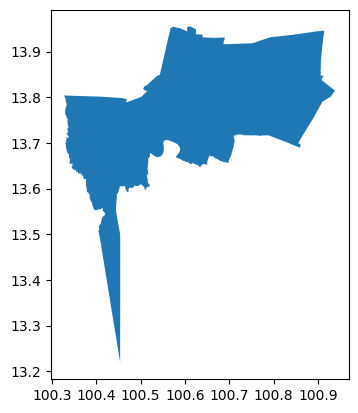

In [4]:
bkk_boundary.plot()

# Project data to epsg 32647

## Bike sharing location

In [5]:
bike_sharing_loc = gpd.read_file('data/punpunbike/punpunbike.shp', encoding="tis-620")

In [6]:
bike_sharing_loc = bike_sharing_loc.set_crs(epsg=4326, allow_override=True)
bike_sharing_loc = bike_sharing_loc.to_crs(epsg=32647)

<Axes: >

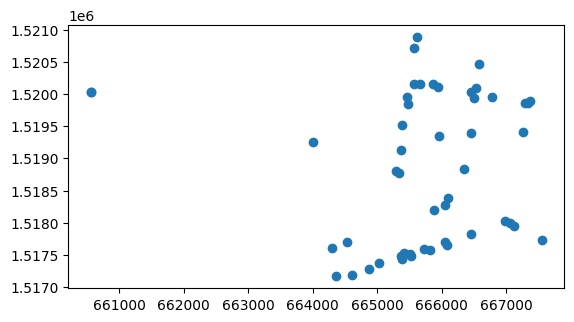

In [7]:
bike_sharing_loc.plot()

## bike route

In [8]:
bike_route = gpd.read_file('data/bike_way/bike_way.shp', encoding="tis-620")

In [9]:
bike_route = bike_route.to_crs(epsg=32647)

<Axes: >

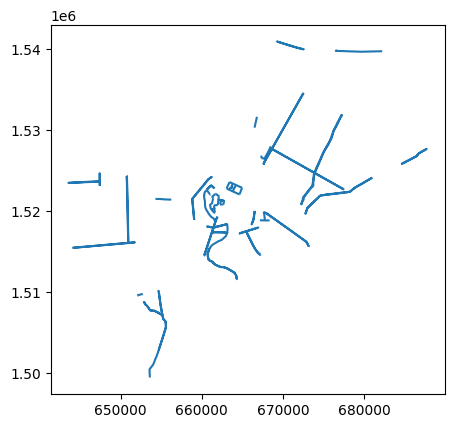

In [10]:
bike_route.plot()

### Create buffer from bike route (~500 m)

In [11]:
bike_route_buffer_df = bike_route.copy()
bike_route_buffer_df['geometry'] = bike_route_buffer_df.geometry.buffer(400)

<Axes: >

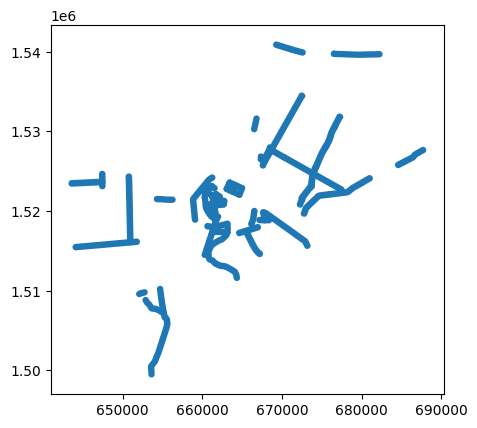

In [12]:
bike_route_buffer_df.plot()

Interested tags
- amenity = cafe, ice_cream, restaurant, arts_centre, fountain
- building = religious, temple
- historic = *
- leisure = park, nature_reserve
- shop = bakery, coffee, food, ice_cream, pastry, department_store
- tourism = attraction, information, viewpoint, zoo

In [13]:
# poi_tags = {'amenity': ['restaurant', 'cafe', 'ice_cream', 'arts_centre', 'fountain'],
#             'building': ['religious', 'temple'],
#             'historic': '*',
#             'leisure': ['park', 'nature_reserve'],
#             'shop': ['bakery', 'coffee', 'food', 'ice_cream', 'pastry', 'department_store'],
#             'tourism': ['attraction', 'information', 'viewpoint', 'zoo']
#             }

poi_tags = {'building': ['religious', 'temple'],
            'historic': True,
            'leisure': ['park', 'nature_reserve'],
            'shop': ['bakery', 'coffee', 'food', 'ice_cream', 'pastry', 'department_store'],
            'tourism': ['attraction', 'viewpoint', 'zoo']
            }

In [14]:
bike_route_buffer_df = bike_route_buffer_df.to_crs(epsg=4326)

In [15]:
for i in range(len(bike_route_buffer_df)):
    try:
        poi_result = ox.features.features_from_polygon(bike_route_buffer_df['geometry'].loc[i], poi_tags)
        if poi_result.empty:
            print(f"No POIs found in buffer {i}")
        
        if i==0:
            poi_df = poi_result.copy()
        else:
            poi_df = pd.concat([poi_df, poi_result], ignore_index=True)
    except InsufficientResponseError:
        print(f"No matching features in polygon {i} - skipping")
        continue
    except Exception as e:
        print(f"Other error in polygon {i}: {e}")
        continue

No matching features in polygon 31 - skipping
No matching features in polygon 32 - skipping


In [16]:
# # Calculate center point for map
# center_lat = bike_route_buffer_df.geometry.centroid.y.mean()
# center_lon = bike_route_buffer_df.geometry.centroid.x.mean()

# Create folium map
# m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles='OpenStreetMap')
m = folium.Map(zoom_start=13, tiles='OpenStreetMap')

# Add buffer zones
folium.GeoJson(
    bike_route_buffer_df.to_json(),
    style_function=lambda x: {'fillColor': 'blue', 'color': 'blue', 'weight': 2, 'fillOpacity': 0.3}
).add_to(m)

# Add POIs
folium.GeoJson(
    poi_df[~poi_df['name'].isna()].to_json(),
    popup=folium.GeoJsonPopup(fields=['name']),
    marker=folium.CircleMarker(radius=5, color='red', fillColor='red', fillOpacity=0.8)
).add_to(m)

# Display map
m

# Convert shape file as geojson

In [17]:
bike_route = bike_route.to_crs(epsg=4326)
bike_sharing_loc = bike_sharing_loc.to_crs(epsg=4326)

In [18]:
bike_route.to_file('data/bike_way/bike_way.geojson', driver='GeoJSON')
bike_sharing_loc.to_file('data/punpunbike/punpunbike.geojson', driver='GeoJSON')

# Save buffer of bike route

<Axes: >

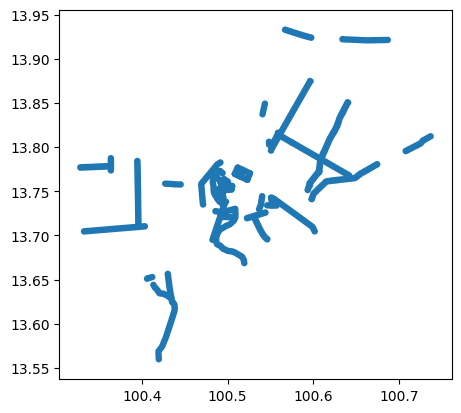

In [19]:
bike_route_buffer_df.plot()

In [20]:
bike_route_buffer_df.to_file('data/bike_way_buffer/bike_way_buffer.geojson', driver='GeoJSON')

# New bike sharing loc

In [31]:
anywheel = gpd.read_file('data/bike_sharing_loc/Anywheel-58.kml')
qad = gpd.read_file('data/bike_sharing_loc/QADs-113.kml')
leo = gpd.read_file('data/bike_sharing_loc/LEO-100.kml')

In [32]:
def parsing_description(df):
    # use regex to extract info
    df['location'] = df['Description'].str.extract(r'Location:\s*([^<\n]+)')
    df['lat'] = df['Description'].str.extract(r'Lat:\s*([\d.]+)').astype(float)
    df['long'] = df['Description'].str.extract(r'Long:\s*([\d.]+)').astype(float)
    df['num_bike'] = df['Description'].str.extract(r'num_bike:\s*([\d.]+)').astype(float)
    df['district'] = df['Description'].str.extract(r'District:\s*([^<\n]+)')

    # Clean up any extra whitespace
    df['location'] = df['location'].str.strip()
    df['district'] = df['district'].str.strip()
    
    df.drop(columns=['Description'], inplace=True)

In [33]:
parsing_description(anywheel)
parsing_description(qad)
parsing_description(leo)

In [34]:
bike_sharing_loc = pd.concat([anywheel, qad, leo], ignore_index=True)

In [35]:
bike_sharing_loc

,Name,geometry,location,lat,long,num_bike,district
0,Any001,POINT Z (100.52918 13.73305 0),จามจุรีสแควร์,13.733050,100.529180,10.0,เขตปทุมวัน
1,Any002,POINT Z (100.52894 13.73379 0),ตรงข้ามสามย่านมิตรทาวน์,13.733790,100.528940,10.0,เขตปทุมวัน
2,Any003,POINT Z (100.52938 13.73662 0),พิพิธภัณฑ์เทคโนโลยีทางกายภาพ,13.736620,100.529380,10.0,เขตปทุมวัน
3,Any004,POINT Z (100.52982 13.74011 0),โรงเรียนเตรียมอุดมศึกษา,13.740110,100.529820,10.0,เขตปทุมวัน
4,Any005,POINT Z (100.53024 13.7436 0),มาบุญครอง MBK center,13.743600,100.530240,10.0,เขตปทุมวัน
...,...,...,...,...,...,...,...
266,LEO096,POINT Z (100.55675 13.73975 0),อาคาร HYATT REGENCY Bangkok Sukhumvit,13.739750,100.556750,5.0,วัฒนา
267,LEO097,POINT Z (100.55769 13.73906 0),โรงแรมโซฟิเทลกรุงเทพสุขุมวิท,13.739056,100.557694,5.0,คลองเตย
268,LEO098,POINT Z (100.55914 13.73803 0),The Westin Grande Sukhumvit Bangkok,13.738028,100.559139,5.0,คลองเตย
269,LEO099,POINT Z (100.53386 13.75661 0),ร้านชานชาลา (BTS พญาไท ทิศตะวันออก),13.756611,100.533861,5.0,ราชเทวี


In [36]:
bike_sharing_loc.to_file('data/bike_sharing_loc/all_bike_sharing_loc.geojson', driver='GeoJSON')